In [169]:
import torch
import numpy as np
import pandas as pd
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from PIL import Image

import tarfile
import io

from helper_functions import show_masks

In [170]:
# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


In [171]:
# Function to predict the mask of an image
def predictMask(img, predictor, input_point = np.empty((0, 2)), input_label = np.empty((0,), dtype=int)):    
    predictor.set_image(img)
    pred_masks, scores, logits = predictor.predict(
        point_coords = input_point,
        point_labels = input_label,
        multimask_output = False
     )
    return pred_masks, scores, logits

In [172]:
# Define the pretrained model configuration you want to use
modelPath = "../sam2_river_masking.pt"
metaDataPath = "../mask_meta.csv"
metaData = pd.read_csv(metaDataPath)
metaData = metaData[metaData['rapid_split'] == 'test']

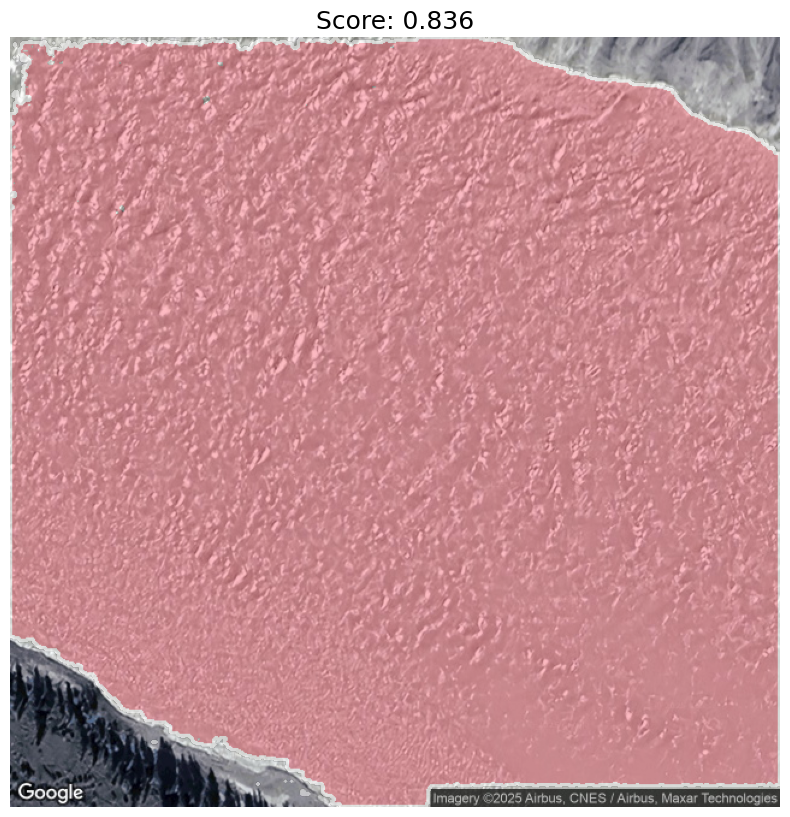

In [173]:
sam2_checkpoint = "../../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "./configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor1 = SAM2ImagePredictor(sam2_model)
# Load the model state that we trained
predictor1.model.load_state_dict(torch.load(modelPath))

tar_path = "../mask_dataset.tar"
key = metaData["image"].iloc[22]
key_img = key + ".jpg"
key_mask = key + ".npy"
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")

pred_masks, scores, logits = predictMask(image, predictor1)
show_masks(image, pred_masks, scores, borders=True)

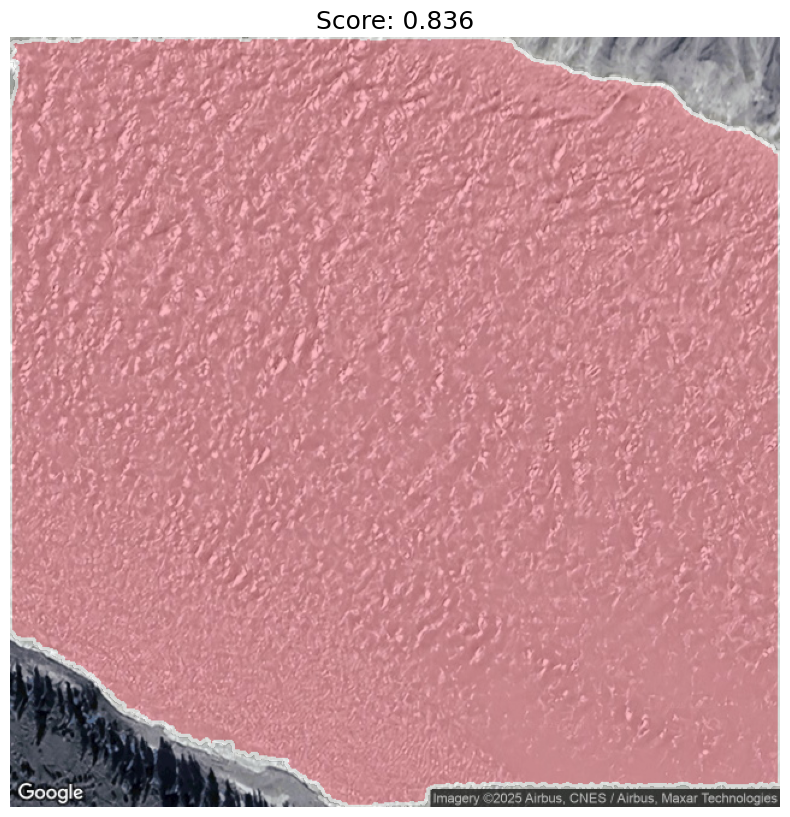

In [174]:
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")
    mask_member = member_dict[key_mask]
    mask_file = tar.extractfile(mask_member)
    mask_content = mask_file.read()
    mask = np.load(io.BytesIO(mask_content))
    mask = np.unpackbits(mask, axis=-1)

pred_masks, scores, logits = predictMask(image, predictor1)
mask = mask.reshape(1, mask.shape[0], mask.shape[1])
show_masks(image, mask, scores, borders=True)